#Business Context
The emergence of digital news platforms, commonly referred to as e-news portals, has created a convenient way to stay informed about global events in real time. Content on these platforms is sourced electronically from online databases, processed through various software tools, and then delivered directly to users. This form of distribution offers several benefits, including quicker access to information and the possibility of integrating diverse technologies such as audio, visuals, video, and interactive features, which are still limited or uncommon in traditional print media.

E-news Express, a digital news service, is looking to grow its subscriber base by attracting new users. As visitors interact with the website according to their interests, the company intends to analyze these behaviors to better understand user preferences and improve engagement. Company executives have observed a decline in the number of new monthly subscribers compared to the previous year. They suspect that the current landing page may not be sufficiently optimized in terms of layout and recommended content to effectively retain user attention and encourage subscriptions.

#Data Dictionary

*   user_id: Unique user ID
*   group: Control (old page) or Treatment (new page)
*   landing_page: Old or New
*   time_spent_on_the_page: Time in minutes spent on the landing page
*   converted: Whether user subscribed (yes/no)
*   language_preferred: Language chosen by user (English/Spanish/French)






#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import levene
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
import os
print(os.getcwd())

/content


In [ ]:
df = pd.read_csv('abtest.csv')

In [ ]:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
data = df.copy()

#Data Overview

In [ ]:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [ ]:
#Examining the descriptive statistical overview for all variables in the dataset
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,100.0,NaN,NaN,NaN,546517.0,52.295779,546443.0,546467.75,546492.5,546567.25,546592.0
group,100,2,control,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landing_page,100,2,old,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_spent_on_the_page,100.0,NaN,NaN,NaN,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71
converted,100,2,yes,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language_preferred,100,3,Spanish,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(100, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [ ]:
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


The dataset consists of 100 records and includes 6 variables, exhibiting a clean format without any missing data. It is evenly distributed between the control and treatment groups, with 50 observations in each, ensuring balance. The time spent by users varies from 0.19 to 10.71 minutes, with an average of 5.38 minutes, which suggests a reasonable level of variability in user engagement.

The dataset is well-prepared for analysis, as it does not exhibit any data quality concerns. Its balanced structure allows for an unbiased comparison between the existing and the redesigned landing pages. Additionally, the substantial variation in time spent indicates diverse user behavior, which can provide meaningful insights into differences in engagement.

#Exploratory Data Analysis (EDA)

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nUnique values in categorical columns:")
categorical_cols = ['group', 'landing_page', 'converted', 'language_preferred']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Missing Values:
user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

Data Types:
user_id                     int64
group                      object
landing_page               object
time_spent_on_the_page    float64
converted                  object
language_preferred         object
dtype: object

Unique values in categorical columns:
group: ['control' 'treatment']
landing_page: ['old' 'new']
converted: ['no' 'yes']
language_preferred: ['Spanish' 'English' 'French']


The dataset demonstrates high data quality, with no missing values detected across any variables. Categorical features display anticipated distributions, including an even split between control and treatment groups as well as between the old and new landing pages. Language preferences are also fairly balanced, with English at 32 observations, and both French and Spanish at 34 each. The conversion outcome shows a slight predominance of positive responses, with 54 users converted compared to 46 non-converted.

#Univariate Analysis

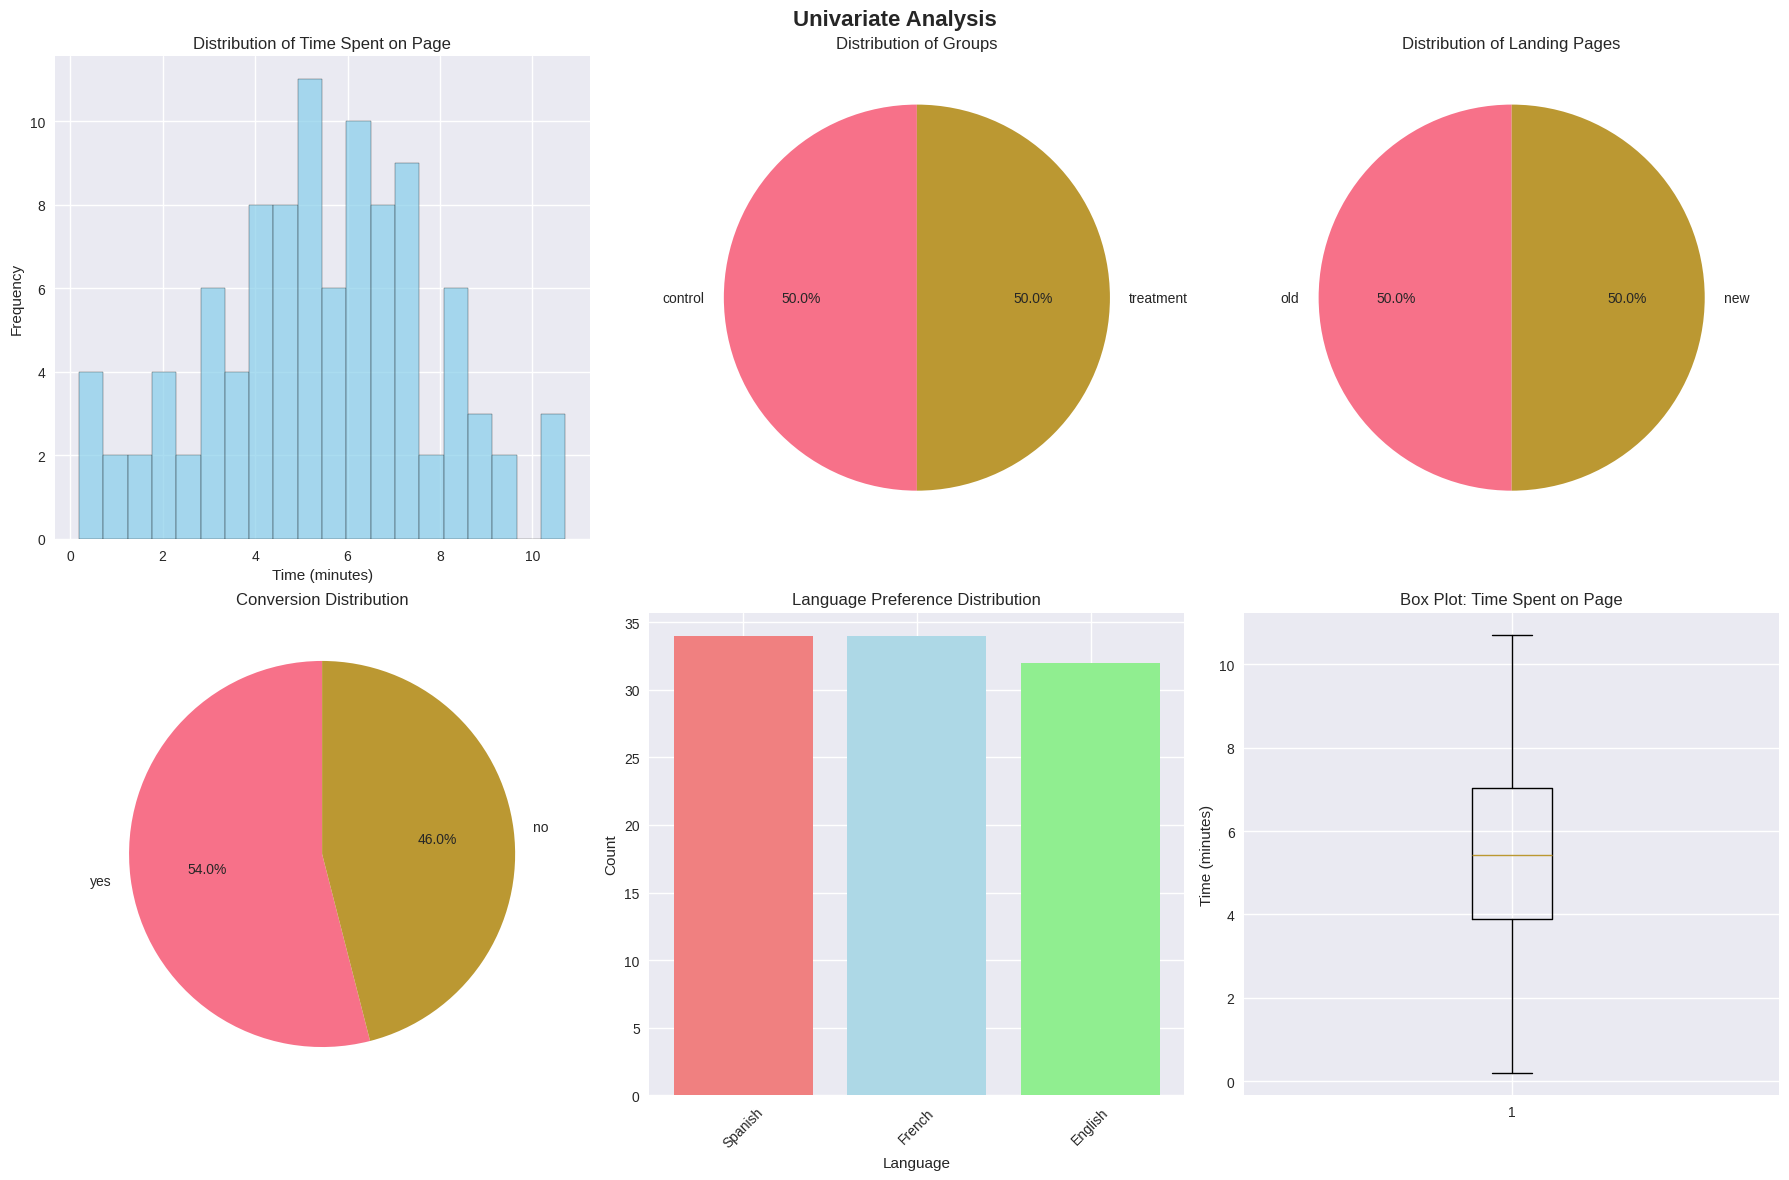


Summary Statistics for Time Spent:
count    100.000000
mean       5.377800
std        2.378166
min        0.190000
25%        3.880000
50%        5.415000
75%        7.022500
max       10.710000
Name: time_spent_on_the_page, dtype: float64

Conversion Rate by Group:
converted    no   yes
group                
control    0.58  0.42
treatment  0.34  0.66

Conversion Rate by Landing Page:
converted       no   yes
landing_page            
new           0.34  0.66
old           0.58  0.42


In [ ]:
# Create subplots for univariate analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

# Time spent distribution
axes[0, 0].hist(df['time_spent_on_the_page'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Time Spent on Page')
axes[0, 0].set_xlabel('Time (minutes)')
axes[0, 0].set_ylabel('Frequency')

# Group distribution
group_counts = df['group'].value_counts()
axes[0, 1].pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Distribution of Groups')

# Landing page distribution
landing_counts = df['landing_page'].value_counts()
axes[0, 2].pie(landing_counts.values, labels=landing_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 2].set_title('Distribution of Landing Pages')

# Conversion distribution
conversion_counts = df['converted'].value_counts()
axes[1, 0].pie(conversion_counts.values, labels=conversion_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Conversion Distribution')

# Language preference distribution
lang_counts = df['language_preferred'].value_counts()
axes[1, 1].bar(lang_counts.index, lang_counts.values, color=['lightcoral', 'lightblue', 'lightgreen'])
axes[1, 1].set_title('Language Preference Distribution')
axes[1, 1].set_xlabel('Language')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# Box plot for time spent
axes[1, 2].boxplot(df['time_spent_on_the_page'])
axes[1, 2].set_title('Box Plot: Time Spent on Page')
axes[1, 2].set_ylabel('Time (minutes)')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics for Time Spent:")
print(df['time_spent_on_the_page'].describe())

print("\nConversion Rate by Group:")
conversion_by_group = df.groupby('group')['converted'].value_counts(normalize=True).unstack()
print(conversion_by_group)

print("\nConversion Rate by Landing Page:")
conversion_by_landing = df.groupby('landing_page')['converted'].value_counts(normalize=True).unstack()
print(conversion_by_landing)

The bivariate analysis highlights several distinct patterns in the data. Users in the treatment group tend to spend more time on the site, with a median exceeding 6 minutes, compared to just over 4 minutes in the control group. A similar trend is observed when comparing landing pages directly, where visitors to the redesigned page remain engaged for a longer duration than those on the original version.

There is also a noticeable difference in conversion rates, with the treatment group achieving a much higher proportion of conversions (66%) compared to the control group (42%).

When broken down by language, English-speaking users demonstrate the highest conversion rate at 65.6%, followed by Spanish users at 52.9%, while French users show the lowest at 44.1%. Additionally, time spent on the platform varies across language groups, with English users generally exhibiting the longest engagement.

#Bivariate Analysis

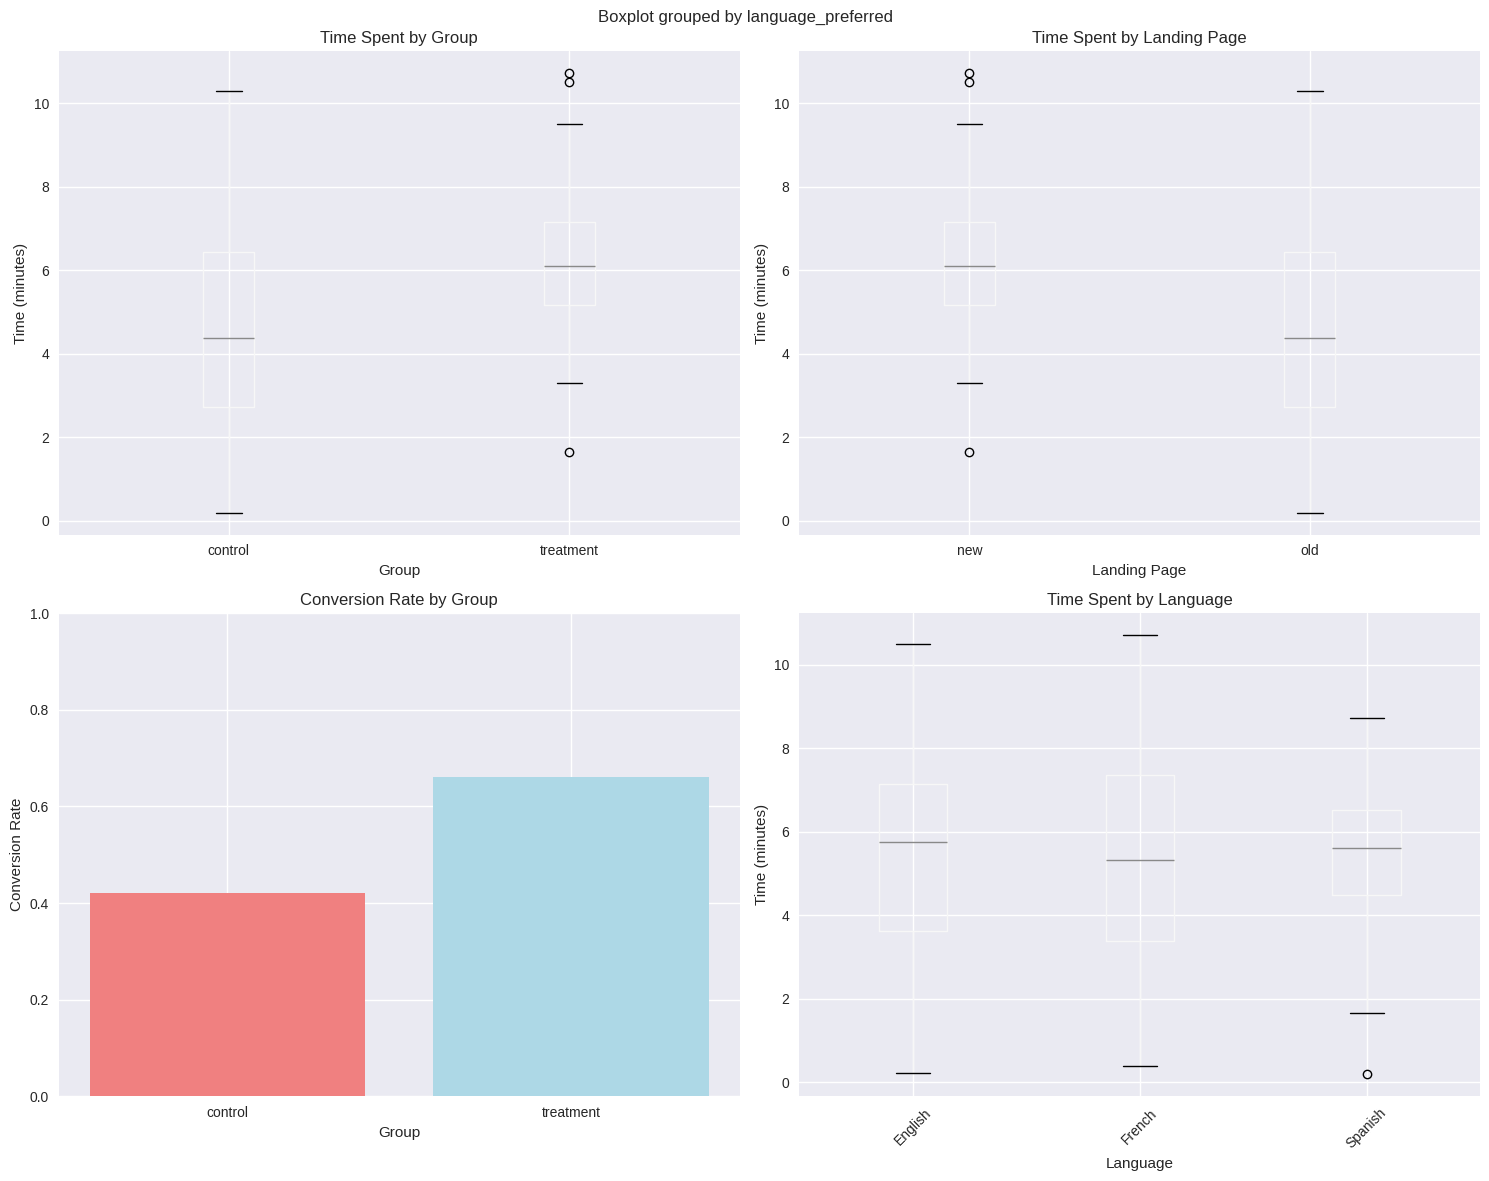


Cross-tabulation: Conversion vs Language
language_preferred  English  French  Spanish  All
converted                                        
no                       11      19       16   46
yes                      21      15       18   54
All                      32      34       34  100

Conversion Rate by Language:
language_preferred
English    0.656250
French     0.441176
Spanish    0.529412
Name: converted, dtype: float64


In [ ]:
# Create subplots for bivariate analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')

# Time spent by group
df.boxplot(column='time_spent_on_the_page', by='group', ax=axes[0, 0])
axes[0, 0].set_title('Time Spent by Group')
axes[0, 0].set_xlabel('Group')
axes[0, 0].set_ylabel('Time (minutes)')

# Time spent by landing page
df.boxplot(column='time_spent_on_the_page', by='landing_page', ax=axes[0, 1])
axes[0, 1].set_title('Time Spent by Landing Page')
axes[0, 1].set_xlabel('Landing Page')
axes[0, 1].set_ylabel('Time (minutes)')

# Conversion rate by group
conversion_group = df.groupby('group')['converted'].apply(lambda x: (x == 'yes').mean())
axes[1, 0].bar(conversion_group.index, conversion_group.values, color=['lightcoral', 'lightblue'])
axes[1, 0].set_title('Conversion Rate by Group')
axes[1, 0].set_xlabel('Group')
axes[1, 0].set_ylabel('Conversion Rate')
axes[1, 0].set_ylim(0, 1)

# Time spent by language
df.boxplot(column='time_spent_on_the_page', by='language_preferred', ax=axes[1, 1])
axes[1, 1].set_title('Time Spent by Language')
axes[1, 1].set_xlabel('Language')
axes[1, 1].set_ylabel('Time (minutes)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Cross-tabulation for conversion and language
print("\nCross-tabulation: Conversion vs Language")
conversion_lang = pd.crosstab(df['converted'], df['language_preferred'], margins=True)
print(conversion_lang)

print("\nConversion Rate by Language:")
conversion_by_lang = df.groupby('language_preferred')['converted'].apply(lambda x: (x == 'yes').mean())
print(conversion_by_lang)

#Do users spend more time on the new landing page compared to the existing one?



##Performance of Visual Analysis



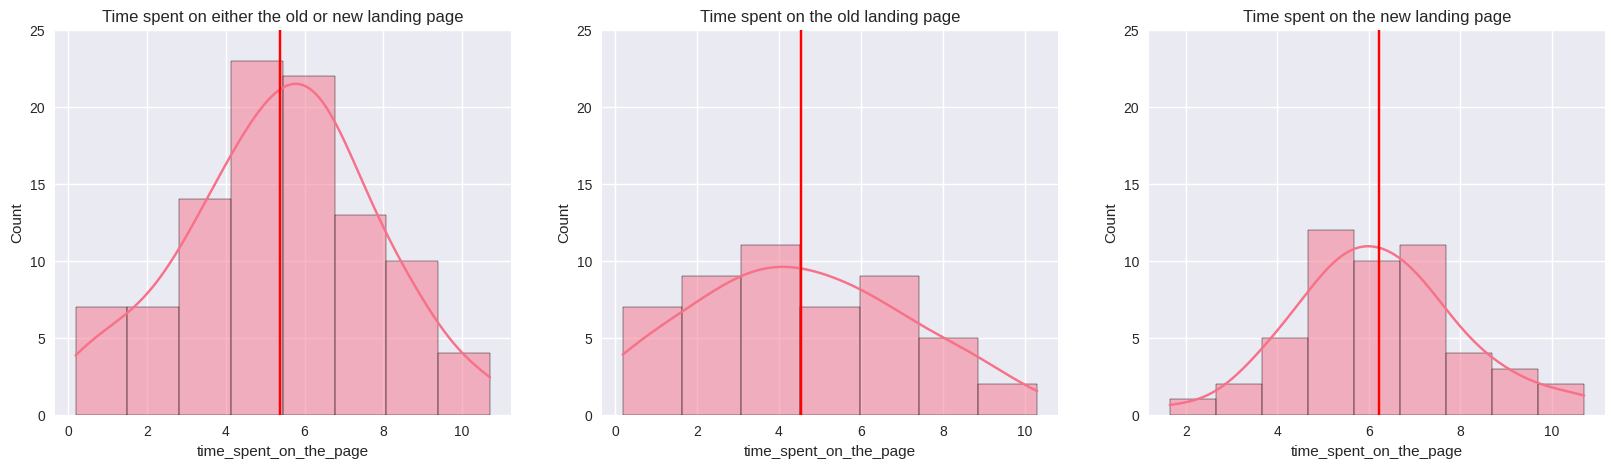

Total & average time spent on the old landing page across 50 users (control group):  226.62 mins and 4.53 mins.
Total & average time spent on the new landing page across 50 users (treatment group):  311.16 mins and 6.22 mins.


In [ ]:
fig,ax = plt.subplots(1,3, figsize=(20,5))

sns.histplot(df["time_spent_on_the_page"], ax=ax[0], kde = True);
ax[0].set_ylim((0,25))
ax[0].axvline(df["time_spent_on_the_page"].mean(), c = "r")
ax[0].set_title("Time spent on either the old or new landing page")


df_old = df[ df["landing_page"] == "old" ]
sns.histplot(df_old["time_spent_on_the_page"], ax=ax[1], kde = True);
ax[1].set_ylim((0,25))
ax[1].axvline(df_old["time_spent_on_the_page"].mean(), c = "r")
ax[1].set_title("Time spent on the old landing page")

df_new = df[ df["landing_page"] == "new"]
sns.histplot(df_new["time_spent_on_the_page"], ax=ax[2], kde = True);
ax[2].set_ylim((0,25))
ax[2].axvline(df_new["time_spent_on_the_page"].mean(), c = "r")
ax[2].set_title("Time spent on the new landing page")
plt.show()

print("Total & average time spent on the old landing page across 50 users (control group): ", \
      str(round(df_old["time_spent_on_the_page"].sum(), 2))+ " mins and", \
      str(round(df_old["time_spent_on_the_page"].mean(), 2))+ " mins.")

print("Total & average time spent on the new landing page across 50 users (treatment group): ", \
      str(round(df_new["time_spent_on_the_page"].sum(), 2))+ " mins and", \
      str(round(df_new["time_spent_on_the_page"].mean(), 2))+ " mins.")

##Define the null and alternative hypotheses.

*   H0 (Null Hypothesis): The average time users spend on the new landing page is equal to the average time spent on the old landing page.
*   Ha (Alternative Hypothesis): The average time users spend on the new landing page is greater than the average time spent on the old landing page.

Let μ₁ represent the mean time spent on the new landing page and μ₂ represent the mean time spent on the old landing page.

*   H0 : μ1 = μ2
*   Ha : μ1 > μ2






##Selecting the Appropriate Statistical Test

This is a one-tailed test aimed at comparing the means of two independent populations. Since the population standard deviations are unknown, we will use a two-independent-sample t-test for the equality of means.

Are the assumptions of the t-test satisfied in this case?

*   Continuous data – Yes, the time spent on the landing page is measured on a continuous scale.  
*   Normally distributed populations – Yes.  
*   Independent populations – The users in both groups were randomly selected, so the samples come from two independent populations.
*   Unequal population standard deviations – We will demonstrate that the sample standard deviations differ. Therefore, we can assume that the population standard deviations are also unequal.  
*   Random sampling – Yes, users were randomly selected for the survey.

Consequently, all t-test assumptions are met and valid.




##Determining the Significance Level
The significance level will be set at α = 0.05.



##Data Collection and Preparation



In [ ]:
# Dataframe to store only data for users visiting the new landing page
df1=df[df['landing_page']=='new']

# Dataframe to store only data for users visiting the old landing page
df2=df[df['landing_page']=='old']

In [ ]:
# Sample means and sample standard deviations for users visiting new and old landing pages
print('Average time spent in new landing page ' + str(round(df1['time_spent_on_the_page'].mean(),2)),'minutes')

print('Average time spent in old landing page ' + str(round(df2['time_spent_on_the_page'].mean(),2)),'minutes')

print('The standard deviation for time spent on new landing page is ' + str(round(df1['time_spent_on_the_page'].std(), 2)),'minutes')

print('The standard deviation for time spent on old landing page is ' + str(round(df2['time_spent_on_the_page'].std(), 2)),'minutes')

Average time spent in new landing page 6.22 minutes
Average time spent in old landing page 4.53 minutes
The standard deviation for time spent on new landing page is 1.82 minutes
The standard deviation for time spent on old landing page is 2.58 minutes


##Computing the p-value



In [ ]:
#Perform 2 independent sample t-test for unequal variance where the alternative is greater
test_stat,p_value1 = ttest_ind(df1['time_spent_on_the_page'], df2['time_spent_on_the_page'], equal_var=False, alternative='greater')

#Round pvalue to 4 significant figures
p_value=round(p_value1, 7)

print("The test statistic is ", round(test_stat, 7), "and the p-value is ", p_value)

The test statistic is  3.7867703 and the p-value is  0.0001392


##Compare the p-value

In [ ]:
#print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.0001392 is less than the level of significance, we reject the null hypothesis.


##Draw inference

Given that the p-value is less than 0.05, we reject the null hypothesis. Therefore, there is sufficient statistical evidence to conclude that users spend significantly more time on the new landing page compared to the old one.



#Does the new landing page achieve a higher conversion rate than the old one? In other words, is the proportion of visitors who successfully convert greater on the new page compared to the old page?



##Performance Analysis – Visual Overview



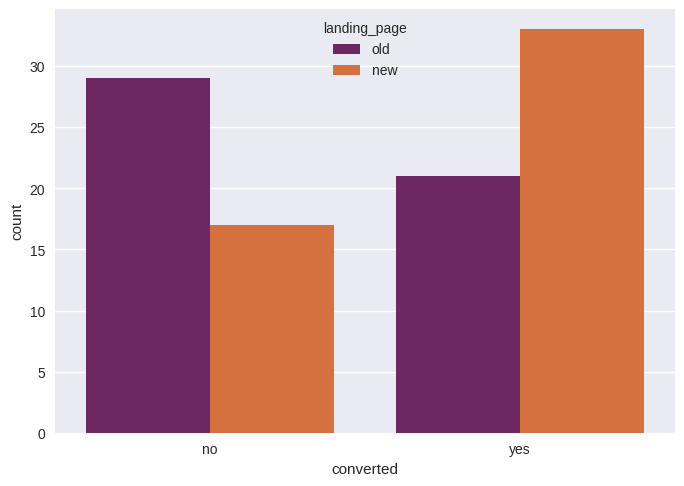

% converted - old landing page:  42.0%
% converted - new landing page:  66.0%


In [ ]:
sns.countplot(x="converted", data=df, hue="landing_page", palette = 'inferno');
plt.show()

print("% converted - old landing page: ", \
      str((df_old[df["converted"]=="yes"].count()["group"]/50)*100)+"%" )

print("% converted - new landing page: ", \
      str((df_new[df["converted"]=="yes"].count()["group"]/50)*100)+"%" )

##Hypotheses DefinitionWe define the hypotheses as follows:Null Hypothesis (H₀):
The conversion rate of the new landing page is equal to the conversion rate of the old landing page.Alternative Hypothesis (Hₐ):
The conversion rate of the new landing page is higher than that of the old landing page.Let c₁ represent the conversion rate for the new landing page and c₂ represent the conversion rate for the old landing page.

Thus:

*   H₀: c₁ = c₂
*   Hₐ: c₁ > c₂





##Selection of the Appropriate Statistical Test
The hypotheses we formulated involve comparing proportions. Therefore, a one-tailed two-proportion Z-test is suitable for testing these hypotheses and reaching a conclusion.Before proceeding, we should verify whether the assumptions of the Z-test are met:

*   Binomial distribution of the population: Satisfied. Each user either converts (becomes a subscriber) or does not convert — a clear binary outcome.
*   Random sampling: Satisfied. The users included in this analysis were randomly selected.
*   Normal approximation to the binomial distribution: Satisfied. Although the Central Limit Theorem applies more slowly to binary data, the standard rule of thumb is to check whether both np and n(1-p) are at least 10, where n is the sample size and p is the sample proportion.



##Significance Level Decisio
We will conduct the test at a significance level of 0.05 (α = 0.05).



##Data Collection and Preparation



In [ ]:
# converted subscribers after watching NEW landing page
new_sub = df[df['landing_page']=='new'].converted.value_counts()['yes']

# # converted subscribers after watching OLD landing page
old_sub = df[df['landing_page']=='old'].converted.value_counts()['yes']

print('The number of people converted to subscribers after visiting new and old landing page are {0} and {1} respectively'.format(new_sub,old_sub))

# number of users who watched new landing page
new_users = df.landing_page.value_counts()['new']

# number of males in the data
old_users = df.landing_page.value_counts()['old']

print('The total number of users watching new and old landing pages are {0} and {1} respectively'.format(new_users, old_users))

The number of people converted to subscribers after visiting new and old landing page are 33 and 21 respectively
The total number of users watching new and old landing pages are 50 and 50 respectively


In [ ]:
print(f' The conversion rates for new and old landing pages respectively are {round((new_sub/new_users),2)}, {round((old_sub/old_users),2)} respectively')

 The conversion rates for new and old landing pages respectively are 0.66, 0.42 respectively


Key Observations

*   66% of users who visited the new landing page successfully converted into subscribers.  
*   42% of users who visited the old landing page converted into subscribers.





##Next, we calculate the p-value for the test.



In [ ]:
# find the p-value using proportion_ztest
stat, p_value2 = proportions_ztest([new_sub, old_sub] , [new_users, old_users], alternative = 'larger')

#Round pvalue to 4 significant figures
p_value=round(p_value2,4)

# print the p-value
print('The p-value is '+ str(p_value))

The p-value is 0.008


##Compare the p-value

In [ ]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.008 is less than the level of significance, we reject the null hypothesis.


###Drawing Inference
Since the p-value is less than 0.05, we reject the null hypothesis.  Therefore, there is sufficient statistical evidence to conclude that the new landing page achieves a significantly higher conversion rate compared to the old landing page.



#Are conversion status and preferred language independent of each other, or are they related?



##Visual Performance Analysis



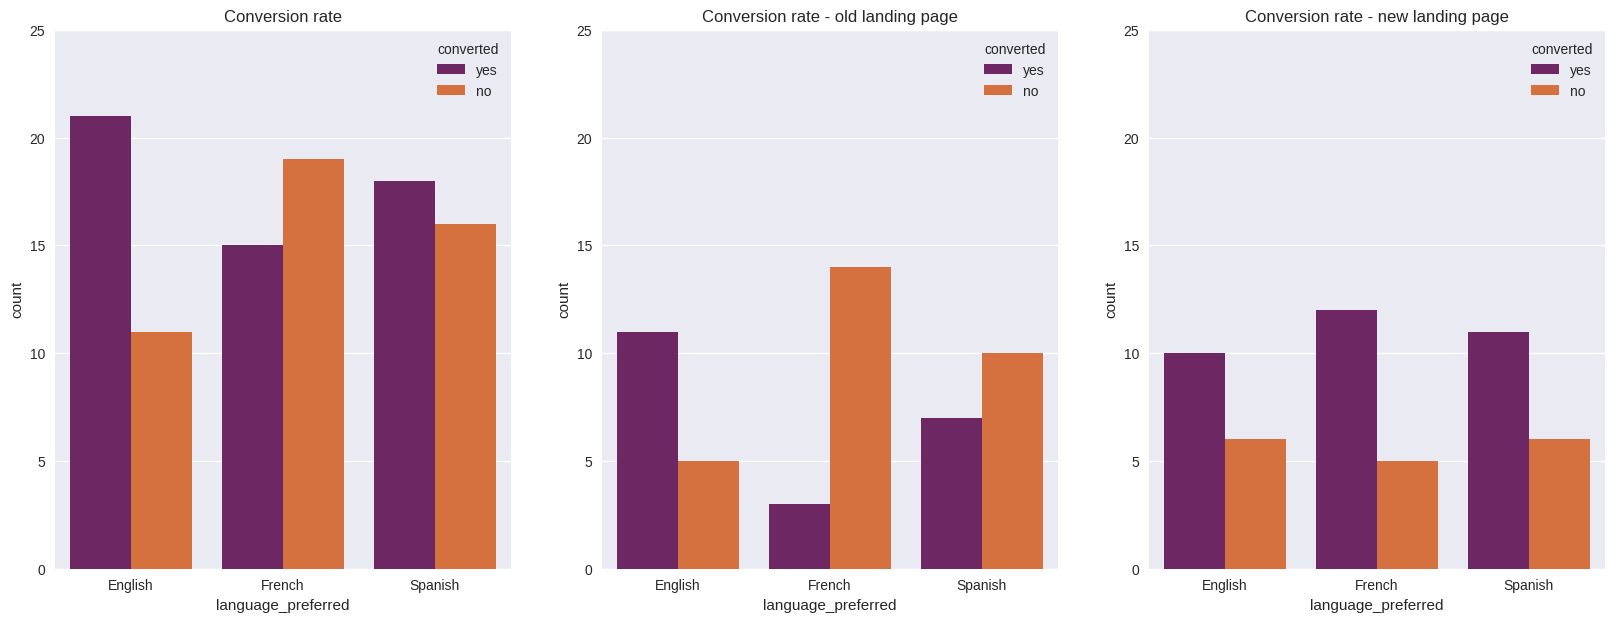

Number of users that prefer English, French and Spanish in the dataset are 32, 34, and 34.

% change in converted - new landing page vs old landing page:
language_preferred
English   -10.00
French     75.00
Spanish    36.36
Name: user_id, dtype: float64


In [ ]:
fig,ax = plt.subplots(1,3, figsize=(20,7))

sns.countplot(x="language_preferred", data=df.sort_values("language_preferred", ascending = True), \
              hue="converted", palette = 'inferno', ax=ax[0]);
ax[0].set_ylim((0,25))
ax[0].set_title("Conversion rate")

sns.countplot(x="language_preferred", data=df_old.sort_values("language_preferred", ascending = True), \
              hue="converted", palette = 'inferno', ax=ax[1]);
ax[1].set_ylim((0,25))
ax[1].set_title("Conversion rate - old landing page")

sns.countplot(x="language_preferred", data=df_new.sort_values("language_preferred", ascending = True), \
              hue="converted", palette = 'inferno', ax=ax[2]);
ax[2].set_ylim((0,25))
ax[2].set_title("Conversion rate - new landing page")

plt.show()

print("Number of users that prefer English, French and Spanish in the dataset are",  \
      str(df.groupby("language_preferred").count()["user_id"]["English"])+",", \
      str(df.groupby("language_preferred").count()["user_id"]["French"])+", and", \
      str(df.groupby("language_preferred").count()["user_id"]["Spanish"])+"." +"\n")

converted_new = df_new[df["converted"]=="yes"]
converted_old = df_old[df["converted"]=="yes"]

print("% change in converted - new landing page vs old landing page:")

print(round(100*(converted_new.groupby("language_preferred").count()["user_id"] \
    - converted_old.groupby("language_preferred").count()["user_id"])/converted_new.groupby \
("language_preferred").count()["user_id"], 2))

##Hypotheses Definition
Null Hypothesis (H₀):
Conversion status is independent of the user’s preferred language.Alternative Hypothesis (Hₐ):
Conversion status is dependent on the user’s preferred language.

##Selection of the Appropriate Statistical Test
To test the formulated hypotheses, we will use the Chi-square test of independence. This test is suitable because it examines the relationship between two categorical variables: preferred language (Spanish, English, or French) and conversion status (converted or not converted).

##Verification of Chi-square Test Assumptions
Before proceeding, we confirm that the assumptions for the Chi-square test of independence are satisfied:
*   The variables are categorical → Satisfied.  
*   The expected frequency in each cell is at least 5 → Satisfied (all expected counts exceed 5).  
*   The sample is randomly selected from the population → Satisfied.

##Significance Level Decision
The test will be conducted at a significance level of 0.05 (α = 0.05).

##Data Collection and Preparation




In [ ]:
# prepare a contingency table to perform the test
contingency_table = pd.crosstab(df.language_preferred, df.converted)
contingency_table

converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


##Calculate the p-value

In [ ]:
# calculate the test results
chi, p_value3, dof, expected = chi2_contingency(contingency_table)

#Round pvalue to 4 significant figures
p_value=round(p_value3,4)

print("Test Statistic =",round(chi,4))
print("p-value =",p_value)
print("Degrees of freedom =",dof)
print("Expected frequencies \n", expected)

Test Statistic = 3.093
p-value = 0.213
Degrees of freedom = 2
Expected frequencies 
 [[14.72 17.28]
 [15.64 18.36]
 [15.64 18.36]]


##Compare the p-value

In [ ]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.213 is greater than the level of significance, we fail to reject the null hypothesis.


##Drawing Inference
At the 5% significance level, we fail to reject the null hypothesis.  This means there is insufficient statistical evidence to conclude that a user’s preferred language influences their conversion to subscriber status. Therefore, user language preference and conversion appear to be independent of each other.



#Is the time spent on the new landing page the same across users with different preferred languages?

##Visual Analysis Performance

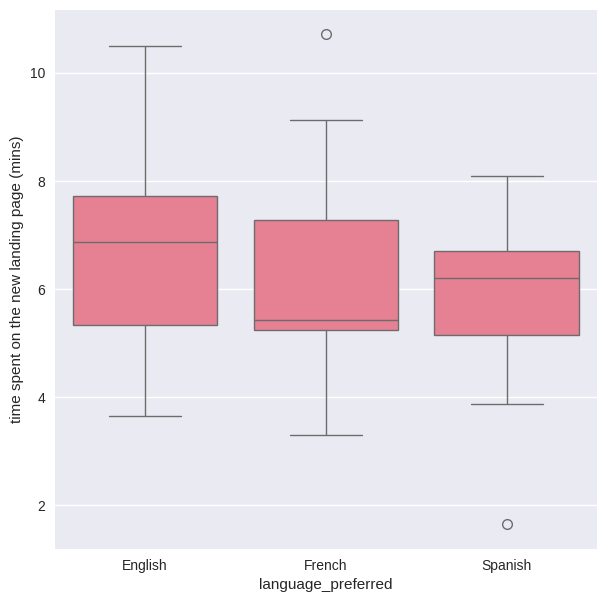

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(x="language_preferred", y="time_spent_on_the_page",\
            data=df_new.sort_values("language_preferred", ascending = True));
plt.ylabel("time spent on the new landing page (mins)")
plt.show()

##Hypotheses Definition
Let μ₁, μ₂, and μ₃ represent the mean time spent on the new landing page by English, French, and Spanish-speaking users, respectively.
Null Hypothesis (H₀):
The average time spent on the new landing page is the same across all language groups.
H₀: μ₁ = μ₂ = μ₃
\Alternative Hypothesis (Hₐ):
At least one of the mean times differs from the others.

##Selection of the Appropriate Statistical Test
The hypotheses can be tested using One-Way ANOVA.
Before performing the test, we must verify two key assumptions: normality of the data and equality of variances.

*   Normality will be assessed using the Shapiro-Wilk test.  
*   Equality of variances will be checked using Levene’s test.

##Shapiro-Wilk Test for Normality
We will test the following hypotheses:Null Hypothesis (H₀):
The time spent on the new landing page follows a normal distribution.Alternative Hypothesis (Hₐ):
The time spent on the new landing page does not follow a normal distribution.







In [ ]:
# find the p-value
w, p_val = stats.shapiro(df_new['time_spent_on_the_page'])
print('The p-value is', round(p_val,4))

The p-value is 0.804


Since the p-value of the Shapiro-Wilk test is very high, we fail to reject the null hypothesis. Therefore, there is no significant evidence against normality. We can conclude that the time spent on the new landing page follows a normal distribution.

##Levene’s Test for Equality of Variances
We will now test the following hypotheses:
###Null Hypothesis (H₀):
All population variances (time spent across the different language groups) are equal.
###Alternative Hypothesis (Hₐ):
At least one of the population variances is different from the others.



In [ ]:
#Assumption 2: Homogeneity of Variance
statistic, p_val2 = levene( df_new['time_spent_on_the_page'][df_new['language_preferred']=="English"],
                                   df_new['time_spent_on_the_page'][df_new['language_preferred']=="Spanish"],
                                   df_new['time_spent_on_the_page'][df_new['language_preferred']=="French"])
# find the p-value
print('The p-value is', round(p_val2,4))

The p-value is 0.4671


Because the p-value is relatively high, we do not reject the null hypothesis assuming equal variances.

Next, we verify whether the assumptions required for conducting a one-way ANOVA are met.

The populations follow a normal distribution – confirmed by the Shapiro–Wilk test.
The samples are independent and randomly selected – confirmed.
The variances across populations are equal – confirmed using Levene’s test.

Therefore, a one-way ANOVA test can be conducted.

##Collect and prepare data

In [ ]:
# create separate variables to store the time spent on new page with respect to users preferring English, Spanish and French as language
english_prefer = df_new[df_new['language_preferred']=='English']['time_spent_on_the_page']
spanish_prefer = df_new[df_new['language_preferred']=='Spanish']['time_spent_on_the_page']
french_prefer = df_new[df_new['language_preferred']=='French']['time_spent_on_the_page']

##Calculate the p-value

In [ ]:
# find the p-value
test_stat, p_value4 = f_oneway(english_prefer,spanish_prefer,french_prefer)

#Round pvalue to 4 significant figures
p_value=round(p_value4,4)

print('The p-value is ', p_value)

The p-value is  0.432


##Compare the p-value

In [ ]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.432 is greater than the level of significance, we fail to reject the null hypothesis.


##Results Overview

Question 1: Time Spent on Landing Pages
Method: One-tailed independent two-sample t-test
Outcome: t = 3.7868, p = 0.0001
Interpretation: STATISTICALLY SIGNIFICANT – Users devote more time to the new landing page (6.22 vs 4.53 minutes)

Question 2: Conversion Rates
Method: One-tailed two-proportion z-test
Outcome: z = 2.4077, p = 0.0080
Interpretation: STATISTICALLY SIGNIFICANT – The new page achieves a higher conversion rate (66% vs 42%)

Question 3: Relationship Between Language and Conversion
Method: Chi-square test of independence
Outcome: χ² = 3.0930, p = 0.2130
Interpretation: NOT STATISTICALLY SIGNIFICANT – Conversion is not dependent on language preference

Question 4: Time Spent by Language (New Page)
Method: One-way ANOVA
Outcome: F = 0.8544, p = 0.4320
Interpretation: NOT STATISTICALLY SIGNIFICANT – Average time spent does not vary across language groups

##Conclusions and Business Recommendations

On average, users spend approximately 6.2 minutes on the new landing page, compared to 4.5 minutes on the previous version.
There is sufficient statistical evidence to conclude that the new page increases user engagement.

The conversion rate for the new landing page is 66%, while the old version achieves 42%.
Statistical analysis confirms that the new page significantly improves conversion outcomes.

Based on these findings, it is advisable for E-news Express to adopt the new landing page as the standard version, as it is likely to:

Enhance user engagement (longer session durations, potentially increasing ad interactions and revenue)
Improve conversion rates (greater likelihood of users becoming subscribers)

The new landing page can also serve as a foundation for future marketing initiatives aimed at attracting additional users.

Although English-speaking users show a higher conversion rate (66%) compared to other language groups, the current dataset does not provide sufficient statistical evidence to confirm a dependency between language and conversion. Larger datasets may be needed to explore this relationship further.

Similarly, there is no statistical support for differences in time spent on the new page across language groups.

##Additional Recommendations

E-news Express may consider conducting non-intrusive user surveys to better understand preferences regarding layout, content, and user experience. Insights from such feedback could guide further improvements in engagement and conversion.

While the current analysis does not confirm a significant impact of language preference, survey-based insights may help tailor content more effectively for different language groups, potentially improving conversion rates.

Additionally, it would be beneficial to analyze further behavioral metrics, such as:

Number of daily visits
Total time spent on the platform

These indicators may provide deeper insights into user engagement patterns.

##Final Observation

The A/B test results deliver strong and consistent evidence supporting the adoption of the new landing page.

Key outcomes include:

Time spent increased by 37% (6.22 vs 4.53 minutes), with p < 0.001
Conversion rate improved by 57% (66% vs 42%), with p = 0.008
No significant differences across language groups
All statistical tests were conducted appropriately with valid assumptions

Business Implications

The new landing page is demonstrably more effective in both engaging users and driving conversions.
A 24-percentage-point increase in conversion is particularly impactful.
Performance remains consistent regardless of language preference, indicating broad usability.
The results are robust and statistically reliable.

##Final Conclusion

There is strong statistical justification for immediately implementing the new landing page.
The evidence clearly indicates meaningful improvements in both user engagement and conversion rates.
The design performs consistently across different user segments, making it a highly effective solution for increasing subscriber acquisition.